# Household Carbon Footprint Prediction

## Problem Statement
Predict a household's annual carbon emission from its lifestyle and consumption habits — transport, diet, energy use, waste, and shopping patterns — using linear regression, to understand which everyday choices contribute most to a household's carbon footprint.

## About the Data
This dataset contains 10,000 household records with 20 features covering transport habits (vehicle type, monthly distance, air travel frequency), diet and lifestyle (diet type, shower frequency, social activity), household energy use (heating source, energy efficiency), waste and recycling habits, and spending patterns (grocery bill, new clothes purchased), with the target variable being the household's total annual CarbonEmission.

In [2]:
# Load the Dataset & Clean Column Names

import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\Imarticus\Machine Learning\HW\Regression Home Assignment\Carbon Emission - LMS.csv")
df.columns = df.columns.str.strip().str.replace(' ', '_')
df.shape

(10000, 20)

In [3]:
# Check for Duplicates

df.duplicated().sum()

np.int64(0)

In [5]:
# Check Missing Values

df.isnull().sum()

Body_Type                           0
Sex                                 0
Diet                                0
How_Often_Shower                    0
Heating_Energy_Source               0
Transport                           0
Vehicle_Type                     6721
Social_Activity                     0
Monthly_Grocery_Bill                0
Frequency_of_Traveling_by_Air       0
Vehicle_Monthly_Distance_Km         0
Waste_Bag_Size                      0
Waste_Bag_Weekly_Count              0
How_Long_TV_PC_Daily_Hour           0
How_Many_New_Clothes_Monthly        0
How_Long_Internet_Daily_Hour        0
Energy_efficiency                   0
Recycling                           0
Cooking_With                        0
CarbonEmission                      0
dtype: int64

In [6]:
pd.crosstab(df['Transport'], df['Vehicle_Type'].isnull())

Vehicle_Type,False,True
Transport,,
private,3279,0
public,0,3294
walk/bicycle,0,3427


In [7]:
# Fill Vehicle_Type with "None"

df['Vehicle_Type'] = df['Vehicle_Type'].fillna('None')
df['Vehicle_Type'].value_counts()

Vehicle_Type
None        6721
lpg          697
electric     671
petrol       647
hybrid       642
diesel       622
Name: count, dtype: int64

In [8]:
# Feature Engineering

print(df['Recycling'].unique())
print(df['Cooking_With'].unique())

["['Metal']" "['Paper', 'Plastic', 'Glass', 'Metal']" "['Paper']"
 "['Paper', 'Glass', 'Metal']" '[]' "['Paper', 'Plastic', 'Glass']"
 "['Glass']" "['Paper', 'Plastic']" "['Plastic']"
 "['Plastic', 'Glass', 'Metal']" "['Paper', 'Plastic', 'Metal']"
 "['Paper', 'Glass']" "['Paper', 'Metal']" "['Glass', 'Metal']"
 "['Plastic', 'Glass']" "['Plastic', 'Metal']"]
["['Stove', 'Oven']" "['Stove', 'Microwave']" "['Oven', 'Microwave']"
 "['Microwave', 'Grill', 'Airfryer']" "['Oven']"
 "['Stove', 'Oven', 'Microwave']" "['Grill', 'Airfryer']" "['Stove']"
 "['Stove', 'Oven', 'Microwave', 'Grill', 'Airfryer']"
 "['Oven', 'Microwave', 'Grill', 'Airfryer']"
 "['Stove', 'Grill', 'Airfryer']" "['Oven', 'Grill', 'Airfryer']"
 "['Microwave']" "['Stove', 'Oven', 'Grill', 'Airfryer']"
 "['Stove', 'Microwave', 'Grill', 'Airfryer']" '[]']


In [9]:
# Convert Multi-Value Columns into Binary Flags

import ast

df['Recycling_List'] = df['Recycling'].apply(ast.literal_eval)
df['Cooking_With_List'] = df['Cooking_With'].apply(ast.literal_eval)

recycling_items = ['Paper', 'Plastic', 'Glass', 'Metal']
cooking_items = ['Stove', 'Oven', 'Microwave', 'Grill', 'Airfryer']

for item in recycling_items:
    df[f'Recycles_{item}'] = df['Recycling_List'].apply(lambda x: int(item in x))

for item in cooking_items:
    df[f'Cooks_With_{item}'] = df['Cooking_With_List'].apply(lambda x: int(item in x))

df['Recycling_Count'] = df['Recycling_List'].apply(len)
df['Cooking_With_Count'] = df['Cooking_With_List'].apply(len)

df[['Recycles_Paper', 'Recycles_Plastic', 'Recycles_Glass', 'Recycles_Metal', 'Recycling_Count',
    'Cooks_With_Stove', 'Cooks_With_Oven', 'Cooks_With_Microwave', 'Cooks_With_Grill',
    'Cooks_With_Airfryer', 'Cooking_With_Count']].head()

,Recycles_Paper,Recycles_Plastic,Recycles_Glass,Recycles_Metal,Recycling_Count,Cooks_With_Stove,Cooks_With_Oven,Cooks_With_Microwave,Cooks_With_Grill,Cooks_With_Airfryer,Cooking_With_Count
0,0,0,0,1,1,1,1,0,0,0,2
1,0,0,0,1,1,1,0,1,0,0,2
2,0,0,0,1,1,0,1,1,0,0,2
3,1,1,1,1,4,0,0,1,1,1,3
4,1,0,0,0,1,0,1,0,0,0,1


In [10]:
# Derived Feature: Air Travel Score

df['Frequency_of_Traveling_by_Air'].unique()

array(['frequently', 'rarely', 'never', 'very frequently'], dtype=object)

In [11]:
# Map to Air_Travel_Score

air_travel_map = {'never': 0, 'rarely': 1, 'frequently': 2, 'very frequently': 3}
df['Air_Travel_Score'] = df['Frequency_of_Traveling_by_Air'].map(air_travel_map)
df['Air_Travel_Score'].value_counts()

Air_Travel_Score
3    2540
2    2524
1    2477
0    2459
Name: count, dtype: int64

In [12]:
# Derived Feature: Total Screen Time

df['Total_Screen_Time_Hours'] = df['How_Long_TV_PC_Daily_Hour'] + df['How_Long_Internet_Daily_Hour']
df['Total_Screen_Time_Hours'].describe()

count    10000.000000
mean        24.028300
std         10.205984
min          0.000000
25%         17.000000
50%         24.000000
75%         31.000000
max         48.000000
Name: Total_Screen_Time_Hours, dtype: float64

In [13]:
df['Waste_Bag_Size'].unique()

array(['large', 'extra large', 'small', 'medium'], dtype=object)

In [14]:
# Derived Feature: Waste Volume Index


waste_size_map = {'small': 1, 'medium': 2, 'large': 3, 'extra large': 4}
df['Waste_Bag_Size_Score'] = df['Waste_Bag_Size'].map(waste_size_map)
df['Waste_Volume_Index'] = df['Waste_Bag_Size_Score'] * df['Waste_Bag_Weekly_Count']
df['Waste_Volume_Index'].describe()

count    10000.000000
mean        10.079800
std          7.101259
min          1.000000
25%          4.000000
50%          8.000000
75%         15.000000
max         28.000000
Name: Waste_Volume_Index, dtype: float64

In [15]:
# Derived Feature: Lifestyle Spend Index

grocery_norm = (df['Monthly_Grocery_Bill'] - df['Monthly_Grocery_Bill'].min()) / (df['Monthly_Grocery_Bill'].max() - df['Monthly_Grocery_Bill'].min())
clothes_norm = (df['How_Many_New_Clothes_Monthly'] - df['How_Many_New_Clothes_Monthly'].min()) / (df['How_Many_New_Clothes_Monthly'].max() - df['How_Many_New_Clothes_Monthly'].min())

df['Lifestyle_Spend_Index'] = (grocery_norm + clothes_norm) / 2
df['Lifestyle_Spend_Index'].describe()

count    10000.000000
mean         0.499835
std          0.207200
min          0.000000
25%          0.350753
50%          0.499498
75%          0.650612
max          0.997992
Name: Lifestyle_Spend_Index, dtype: float64

In [16]:
# EDA, Target Variable: CarbonEmission Distribution

df['CarbonEmission'].describe()

count    10000.000000
mean      2269.147300
std       1017.675247
min        306.000000
25%       1538.000000
50%       2080.000000
75%       2768.000000
max       8377.000000
Name: CarbonEmission, dtype: float64

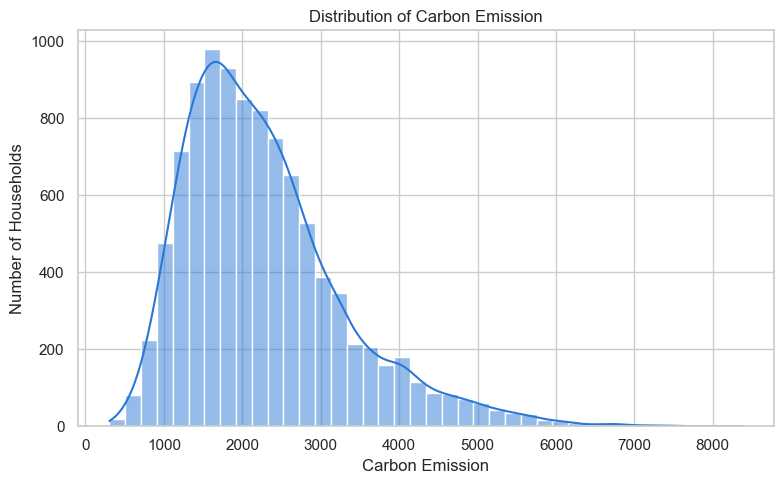

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='CarbonEmission', bins=40, color='#2a78d6', kde=True)
plt.title('Distribution of Carbon Emission')
plt.xlabel('Carbon Emission')
plt.ylabel('Number of Households')
plt.tight_layout()
plt.show()

In [18]:
df['CarbonEmission'].skew()

np.float64(1.1580722842415405)

In [19]:
# Average Emissions by Key Categories

for col in ['Transport', 'Heating_Energy_Source', 'Diet', 'Body_Type']:
    print(df.groupby(col)['CarbonEmission'].mean().sort_values(ascending=False))
    print()

Transport
private         2980.878012
public          1965.789314
walk/bicycle    1879.738547
Name: CarbonEmission, dtype: float64

Heating_Energy_Source
coal           2495.060246
wood           2296.815672
natural gas    2248.124289
electricity    2039.379702
Name: CarbonEmission, dtype: float64

Diet
omnivore       2391.980738
pescatarian    2251.835552
vegetarian     2216.814408
vegan          2215.761314
Name: CarbonEmission, dtype: float64

Body_Type
obese          2561.212000
overweight     2358.919984
normal         2140.509503
underweight    2019.027165
Name: CarbonEmission, dtype: float64



In [20]:
# Correlation of Numeric Predictors with CarbonEmission

numeric_cols = ['Vehicle_Monthly_Distance_Km', 'Air_Travel_Score', 'Waste_Volume_Index',
                 'Total_Screen_Time_Hours', 'Lifestyle_Spend_Index', 'Monthly_Grocery_Bill',
                 'How_Many_New_Clothes_Monthly', 'Waste_Bag_Weekly_Count', 'CarbonEmission']

df[numeric_cols].corr()['CarbonEmission'].sort_values(ascending=False)

CarbonEmission                  1.000000
Vehicle_Monthly_Distance_Km     0.594171
Air_Travel_Score                0.478487
Waste_Volume_Index              0.223251
How_Many_New_Clothes_Monthly    0.198887
Lifestyle_Spend_Index           0.198204
Waste_Bag_Weekly_Count          0.159193
Monthly_Grocery_Bill            0.081587
Total_Screen_Time_Hours         0.040328
Name: CarbonEmission, dtype: float64

In [21]:
# Prepare Final Features & Train/Test Split

drop_cols = ['Recycling', 'Cooking_With', 'Recycling_List', 'Cooking_With_List',
             'Frequency_of_Traveling_by_Air', 'Waste_Bag_Size', 'Waste_Bag_Size_Score',
             'Waste_Bag_Weekly_Count', 'Monthly_Grocery_Bill', 'How_Many_New_Clothes_Monthly',
             'How_Long_TV_PC_Daily_Hour', 'How_Long_Internet_Daily_Hour']

X = df.drop(columns=drop_cols + ['CarbonEmission'])
y = df['CarbonEmission']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(8000, 25) (2000, 25)


In [22]:
# Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(numeric_features)
print(categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

['Vehicle_Monthly_Distance_Km', 'Recycles_Paper', 'Recycles_Plastic', 'Recycles_Glass', 'Recycles_Metal', 'Cooks_With_Stove', 'Cooks_With_Oven', 'Cooks_With_Microwave', 'Cooks_With_Grill', 'Cooks_With_Airfryer', 'Recycling_Count', 'Cooking_With_Count', 'Air_Travel_Score', 'Total_Screen_Time_Hours', 'Waste_Volume_Index', 'Lifestyle_Spend_Index']
['Body_Type', 'Sex', 'Diet', 'How_Often_Shower', 'Heating_Energy_Source', 'Transport', 'Vehicle_Type', 'Social_Activity', 'Energy_efficiency']


In [23]:
# Train the Baseline Linear Regression Model

from sklearn.linear_model import LinearRegression

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
# Evaluate the Model

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = lr_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = len(lr_model.named_steps['preprocessor'].get_feature_names_out())
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("Adjusted R²:", adj_r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.9171608245256078
Adjusted R²: 0.9150792247316358
RMSE: 293.4767126399769
MAE: 211.48059112049623


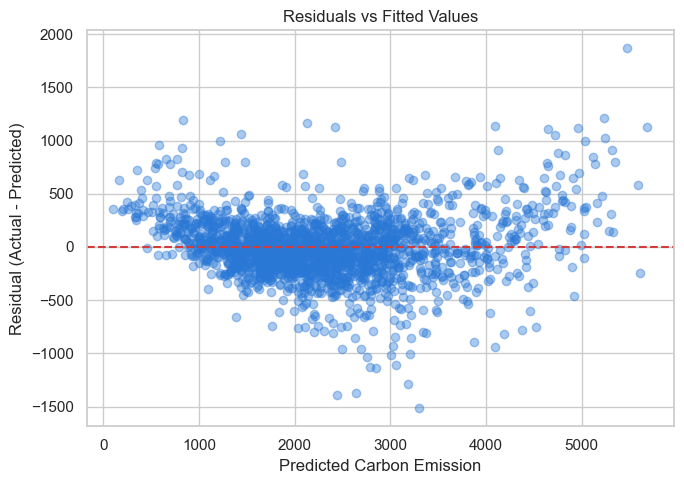

In [25]:
# Residual Diagnostics — Check Linear Regression's Assumptions

residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='#2a78d6')
plt.axhline(0, color='#d03b3b', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Predicted Carbon Emission')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

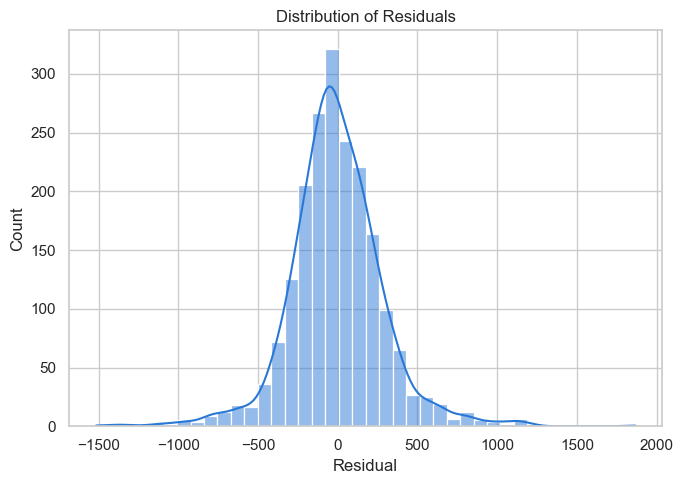

In [26]:
# Check Residual Normality

plt.figure(figsize=(7, 5))
sns.histplot(residuals, bins=40, kde=True, color='#2a78d6')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [27]:
# Interpret Coefficients — Find the Key Drivers

feature_names = lr_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = lr_model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)
coef_df.head(15)

,feature,coefficient,abs_coefficient
39,cat__Vehicle_Type_electric,-1056.903256,1056.903256
42,cat__Vehicle_Type_petrol,808.395390,808.395390
0,num__Vehicle_Monthly_Distance_Km,562.537852,562.537852
12,num__Air_Travel_Score,489.944503,489.944503
41,cat__Vehicle_Type_lpg,322.533213,322.533213
17,cat__Body_Type_obese,294.484387,294.484387
19,cat__Body_Type_underweight,-244.957676,244.957676
40,cat__Vehicle_Type_hybrid,-240.030478,240.030478
14,num__Waste_Volume_Index,227.314811,227.314811
31,cat__Heating_Energy_Source_electricity,-223.639751,223.639751


In [28]:
categorical_transformer_v2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_v2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer_v2, categorical_features)
])

lr_model_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('regressor', LinearRegression())
])

lr_model_v2.fit(X_train, y_train)

feature_names_v2 = lr_model_v2.named_steps['preprocessor'].get_feature_names_out()
coefficients_v2 = lr_model_v2.named_steps['regressor'].coef_

coef_df_v2 = pd.DataFrame({'feature': feature_names_v2, 'coefficient': coefficients_v2})
coef_df_v2['abs_coefficient'] = coef_df_v2['coefficient'].abs()
coef_df_v2 = coef_df_v2.sort_values('abs_coefficient', ascending=False)
coef_df_v2.head(15)

,feature,coefficient,abs_coefficient
32,cat__Vehicle_Type_electric,-1032.870109,1032.870109
35,cat__Vehicle_Type_petrol,832.428537,832.428537
0,num__Vehicle_Monthly_Distance_Km,562.537852,562.537852
12,num__Air_Travel_Score,489.944503,489.944503
26,cat__Heating_Energy_Source_electricity,-436.963572,436.963572
16,cat__Body_Type_obese,423.772192,423.772192
34,cat__Vehicle_Type_lpg,346.566360,346.566360
19,cat__Sex_male,339.721051,339.721051
31,cat__Vehicle_Type_diesel,232.096285,232.096285
14,num__Waste_Volume_Index,227.314811,227.314811


Built a Linear Regression model predicting household CarbonEmission from lifestyle and transport habits (R² = 0.917, MAE ≈ 211 units). Model assumptions checks: residuals are roughly normal and show no curve (linearity holds), but do show heteroscedasticity — prediction error grows for higher-emission households, so estimates are less precise at the high end; a log-transform of the target would be the natural next step to address this.

Biggest emission drivers: vehicle distance driven, air travel frequency, and heating source (coal-heated and high-mileage/high-flying households emit the most). Biggest reducers: electric/hybrid vehicles and cleaner heating (electricity, natural gas, wood all beat coal).